# Parte 1: Análisis de datos sintéticos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generar datos simulados
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}

df = pd.DataFrame(data)

df

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,App Móvil,Transferencia,359,Moda
1,1002,App Móvil,Tarjeta Crédito,62,Hogar
2,1003,App Móvil,Tarjeta Crédito,184,Moda
3,1004,App Móvil,Transferencia,313,Hogar
4,1005,Web Desktop,Transferencia,374,Moda
5,1006,Web Desktop,Tarjeta Crédito,448,Hogar
6,1007,App Móvil,Tarjeta Crédito,64,Hogar
7,1008,App Móvil,Tarjeta Crédito,445,Hogar
8,1009,App Móvil,PayPal,459,Electrónica
9,1010,App Móvil,PayPal,487,Moda


In [2]:
# Mostramos las primeras 5 filas para verificar que todo esté correcto
print("--- Primeras filas del Dataset simulado ---")
print(df.head())


--- Primeras filas del Dataset simulado ---
   ID_Transaccion        Canal      Metodo_Pago  Total_Venta Categoria
0            1001    App Móvil    Transferencia          359      Moda
1            1002    App Móvil  Tarjeta Crédito           62     Hogar
2            1003    App Móvil  Tarjeta Crédito          184      Moda
3            1004    App Móvil    Transferencia          313     Hogar
4            1005  Web Desktop    Transferencia          374      Moda


# KPI 1: Ingreso Total por Canal 

Este indicador calcula la suma bruta de todas las ventas monetarias (`Total_Venta`) realizadas de manera independiente en cada uno de los canales estratégicos: Web Desktop y App Móvil

* **Determinar el volumen de negocio:** Identifica cuál de las dos plataformas está atrayendo la mayor cantidad de capital al negocio.
* **Toma de decisiones:** Permite evaluar si los esfuerzos de marketing y desarrollo están rindiendo frutos en ingresos brutos. Si un canal duplica los ingresos del otro, se convierte automáticamente en la principal fuente de entrada de dinero para la empresa.

--- KPI 1: INGRESO TOTAL POR CANAL ---
      Canal  Ingreso_Total
  App Móvil           9515
Web Desktop           3492




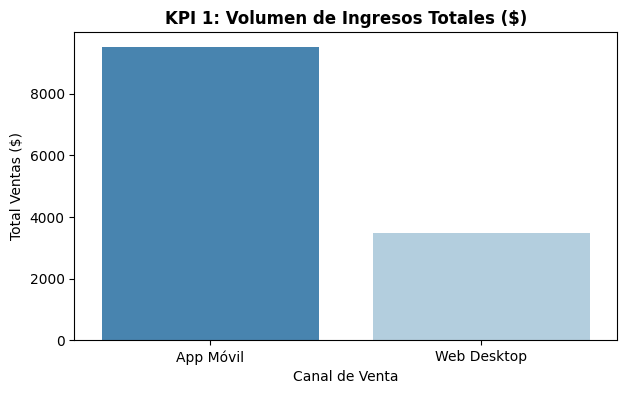

In [3]:
# Cálculo del KPI 1
kpi_1 = df.groupby('Canal')['Total_Venta'].sum().reset_index()
kpi_1.columns = ['Canal', 'Ingreso_Total']

print("--- KPI 1: INGRESO TOTAL POR CANAL ---")
print(kpi_1.to_string(index=False))
print("\n")

# Gráfico del KPI 1 
plt.figure(figsize=(7, 4))
sns.barplot(data=kpi_1, x='Canal', y='Ingreso_Total', hue='Canal', palette='Blues_r', legend=False)
plt.title('KPI 1: Volumen de Ingresos Totales ($)', fontsize=12, fontweight='bold')
plt.ylabel('Total Ventas ($)')
plt.xlabel('Canal de Venta')
plt.show()



## KPI 2: Ticket Promedio por Canal

El Ticket Promedio representa el valor medio de cada transacción. Se calcula dividiendo los ingresos totales del canal entre el número total de compras realizadas en ese mismo canal.

* **Medir la calidad del gasto:** Mientras que el KPI 1 mide volumen, el KPI 2 mide eficiencia. Nos dice en qué canal el cliente está dispuesto a gastar más dinero en una sola sesión de compra.
* **Estrategia comercial:** Si la App Móvil tiene un ticket promedio más alto, significa que los usuarios de la app son más receptivos a productos premium o a compras compuestas (añadir más productos al carrito), lo que suele ser más rentable operativamente.

--- KPI 2: TICKET PROMEDIO POR CANAL (AOV) ---
      Canal  Ticket_Promedio
  App Móvil       264.305556
Web Desktop       249.428571




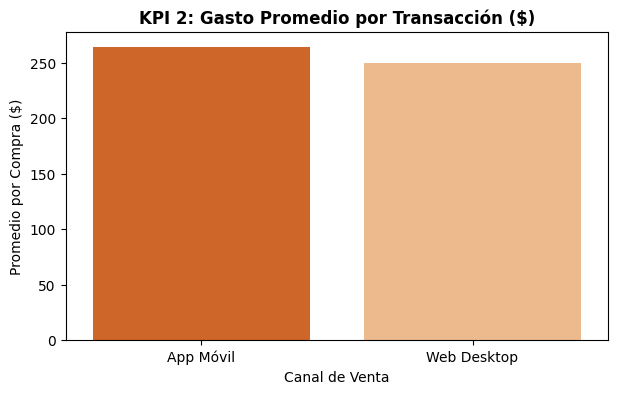

In [4]:
# Cálculo del KPI 2
kpi_2 = df.groupby('Canal')['Total_Venta'].mean().reset_index()
kpi_2.columns = ['Canal', 'Ticket_Promedio']

print("--- KPI 2: TICKET PROMEDIO POR CANAL (AOV) ---")
print(kpi_2.to_string(index=False))
print("\n")

# Gráfico del KPI 2 
plt.figure(figsize=(7, 4))
sns.barplot(data=kpi_2, x='Canal', y='Ticket_Promedio', hue='Canal', palette='Oranges_r', legend=False)
plt.title('KPI 2: Gasto Promedio por Transacción ($)', fontsize=12, fontweight='bold')
plt.ylabel('Promedio por Compra ($)')
plt.xlabel('Canal de Venta')
plt.show()


## KPI 3: Densidad de Transacciones

Este KPI mide la distribución porcentual del volumen total de transacciones operadas por el sistema (TPS) entre la App Móvil y la Web Desktop. No mide dinero, mide el **número de órdenes**.

* **Evaluar la adopción del canal:** Permite entender la preferencia de uso y el hábito del consumidor. 
* **Detección de alertas operativas:** Si la App concentra el 60% de las transacciones pero el KPI 1 (Ingresos) es bajo, significa que los clientes usan mucho la app pero solo para compras muy pequeñas ("compras hormiga"). Esto alertaría sobre un posible problema de costos de envío o comisiones que podrían afectar la rentabilidad neta.

--- KPI 3: DENSIDAD DE TRANSACCIONES (%) ---
      Canal  Porcentaje_Transacciones
  App Móvil                      72.0
Web Desktop                      28.0




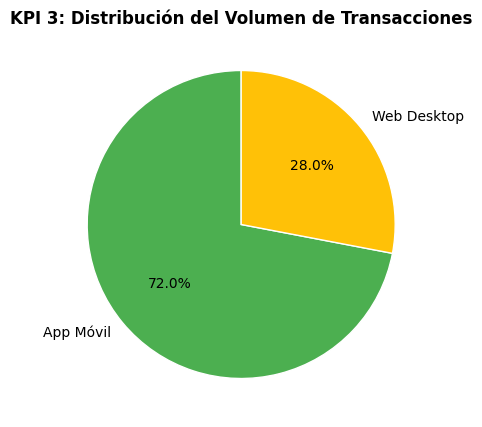

In [5]:
# Cálculo del KPI 3
kpi_3 = df['Canal'].value_counts(normalize=True).reset_index()
kpi_3.columns = ['Canal', 'Porcentaje_Transacciones']
kpi_3['Porcentaje_Transacciones'] = kpi_3['Porcentaje_Transacciones'] * 100

print("--- KPI 3: DENSIDAD DE TRANSACCIONES (%) ---")
print(kpi_3.to_string(index=False))
print("\n")

# Gráfico del KPI 3 
plt.figure(figsize=(5, 5))
plt.pie(kpi_3['Porcentaje_Transacciones'], labels=kpi_3['Canal'], autopct='%1.1f%%', 
        colors=['#4CAF50', '#FFC107'], startangle=90, wedgeprops={'edgecolor': 'white'})
plt.title('KPI 3: Distribución del Volumen de Transacciones', fontsize=12, fontweight='bold')
plt.show()


## KPI 4: Matriz de Ventas por Categoría y Canal

Este indicador cruza las variables de los canales con las categorías de productos (`Electrónica`, `Moda`, `Hogar`), desglosando los ingresos generados por cada tipo de producto en cada plataforma.

* **Alineación de Márgenes de Ganancia:** No todos los productos dejan el mismo beneficio. Por ejemplo, la electrónica suele tener márgenes muy ajustados (bajos), mientras que la moda suele tener márgenes de ganancia altos. 
* **Optimización de Stock y Promociones:** Si el análisis demuestra que el canal "App Móvil" vende mayoritariamente "Moda", la estrategia de M-Commerce se vuelve inherentemente más rentable debido al margen del producto, permitiendo dirigir promociones específicas de esa categoría a los usuarios de la App.

--- KPI 4: VENTAS TOTALES POR CATEGORÍA Y CANAL ---
Categoria    Electrónica  Hogar  Moda
Canal                                
App Móvil           2775   3006  3734
Web Desktop          492   1677  1323




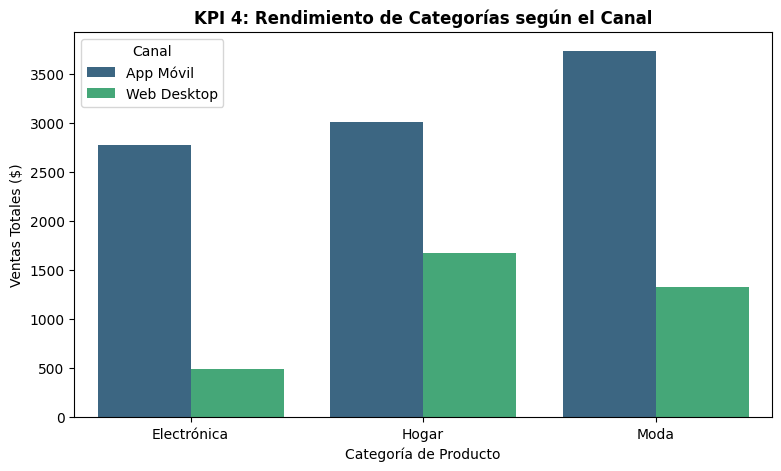

In [6]:
# Cálculo del KPI 4
kpi_4 = df.pivot_table(values='Total_Venta', index='Canal', columns='Categoria', aggfunc='sum').fillna(0)

print("--- KPI 4: VENTAS TOTALES POR CATEGORÍA Y CANAL ---")
print(kpi_4)
print("\n")

# Gráfico del KPI 4
kpi_4_melted = df.groupby(['Canal', 'Categoria'])['Total_Venta'].sum().reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=kpi_4_melted, x='Categoria', y='Total_Venta', hue='Canal', palette='viridis')
plt.title('KPI 4: Rendimiento de Categorías según el Canal', fontsize=12, fontweight='bold')
plt.ylabel('Ventas Totales ($)')
plt.xlabel('Categoría de Producto')
plt.legend(title='Canal')
plt.show()



# Parte 2: KPIs para E-Commerce

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
file_path = '/kaggle/input/datasets/rominavillamarin/trainromina/Train.csv'
df = pd.read_csv(file_path)
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


## 1. KPIs de Gestión de Logística y Operaciones
Análisis de la eficiencia en la distribución, modos de transporte y uso de la infraestructura de almacenamiento.


--- DATOS DE LOGÍSTICA ---

Ocupación por Bodega:
 Warehouse_block  Cantidad_Productos
              F                3666
              D                1834
              A                1833
              B                1833
              C                1833


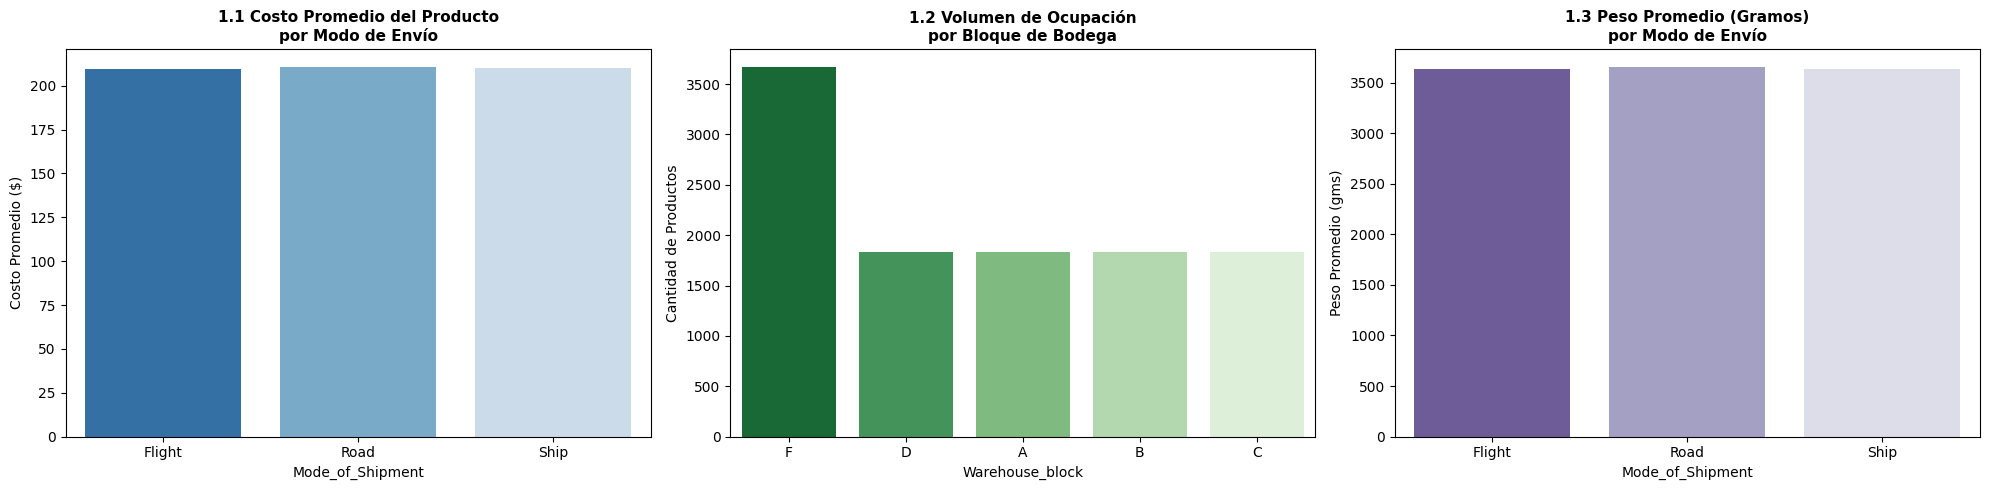

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

kpi_1_1 = df.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean().reset_index()

kpi_1_2 = df['Warehouse_block'].value_counts().reset_index()
kpi_1_2.columns = ['Warehouse_block', 'Cantidad_Productos']

kpi_1_3 = df.groupby('Mode_of_Shipment')['Weight_in_gms'].mean().reset_index()

print("--- DATOS DE LOGÍSTICA ---")
print("\nOcupación por Bodega:\n", kpi_1_2.to_string(index=False))

sns.barplot(data=kpi_1_1, x='Mode_of_Shipment', y='Cost_of_the_Product', hue='Mode_of_Shipment', ax=axes[0], palette='Blues_r', legend=False)
axes[0].set_title('1.1 Costo Promedio del Producto\npor Modo de Envío', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Costo Promedio ($)')

sns.barplot(data=kpi_1_2, x='Warehouse_block', y='Cantidad_Productos', hue='Warehouse_block', ax=axes[1], palette='Greens_r', legend=False)
axes[1].set_title('1.2 Volumen de Ocupación\npor Bloque de Bodega', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Cantidad de Productos')

sns.barplot(data=kpi_1_3, x='Mode_of_Shipment', y='Weight_in_gms', hue='Mode_of_Shipment', ax=axes[2], palette='Purples_r', legend=False)
axes[2].set_title('1.3 Peso Promedio (Gramos)\npor Modo de Envío', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Peso Promedio (gms)')

plt.tight_layout()
plt.show()



## 2. KPIs de Gestión Comercial y Financiera 
Evaluación del rendimiento del dinero, las estrategias de precios y el impacto de los descuentos otorgados.


--- 2.1 MÉTRIQUES DE TICKET Y VOLUMEN ---
Ingreso Total Bruto Comercial: $2,311,955.00
Costo Promedio por Producto (Ticket): $210.20
--------------------------------------------------


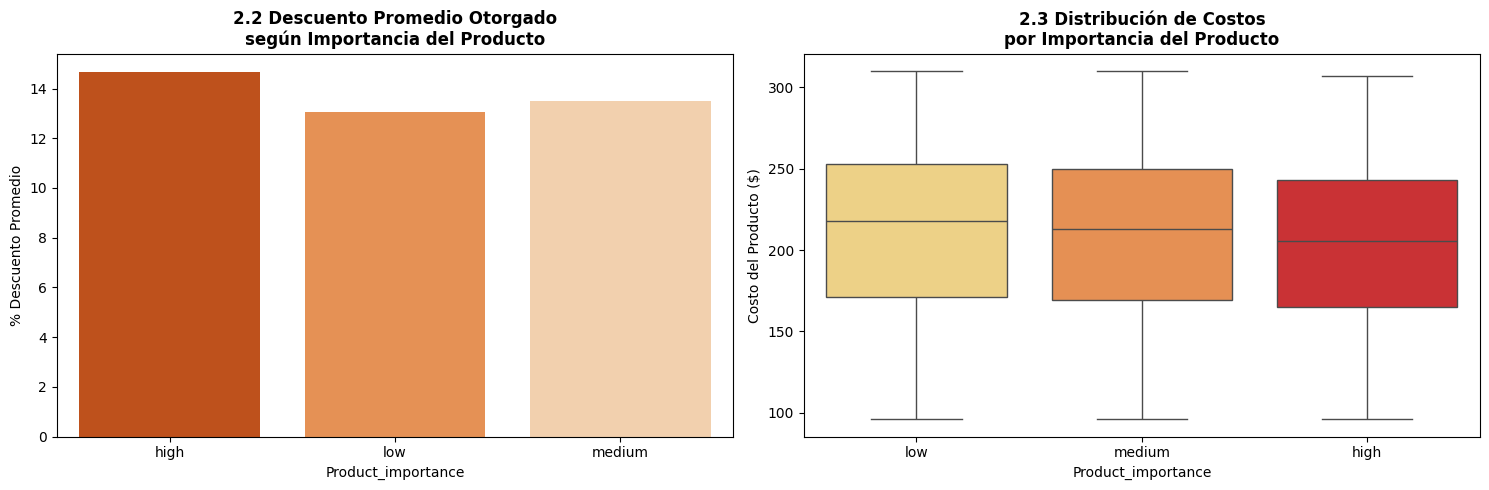

In [9]:
ingreso_total = df['Cost_of_the_Product'].sum()
costo_promedio = df['Cost_of_the_Product'].mean()

print("--- 2.1 MÉTRIQUES DE TICKET Y VOLUMEN ---")
print(f"Ingreso Total Bruto Comercial: ${ingreso_total:,.2f}")
print(f"Costo Promedio por Producto (Ticket): ${costo_promedio:.2f}\n" + "-"*50)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

kpi_2_2 = df.groupby('Product_importance')['Discount_offered'].mean().reset_index()
sns.barplot(data=kpi_2_2, x='Product_importance', y='Discount_offered', hue='Product_importance', ax=axes[0], palette='Oranges_r', legend=False)
axes[0].set_title('2.2 Descuento Promedio Otorgado\nsegún Importancia del Producto', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% Descuento Promedio')

kpi_2_3 = df.groupby('Product_importance')['Cost_of_the_Product'].mean().reset_index()
sns.boxplot(data=df, x='Product_importance', y='Cost_of_the_Product', hue='Product_importance', ax=axes[1], palette='YlOrRd', legend=False)
axes[1].set_title('2.3 Distribución de Costos\npor Importancia del Producto', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Costo del Producto ($)')

plt.tight_layout()
plt.show()


## 3. KPIs de Experiencia y Fidelización del Cliente
Medición de la satisfacción del usuario (CSAT), tasas de retención por compras previas y demanda de soporte post-venta.


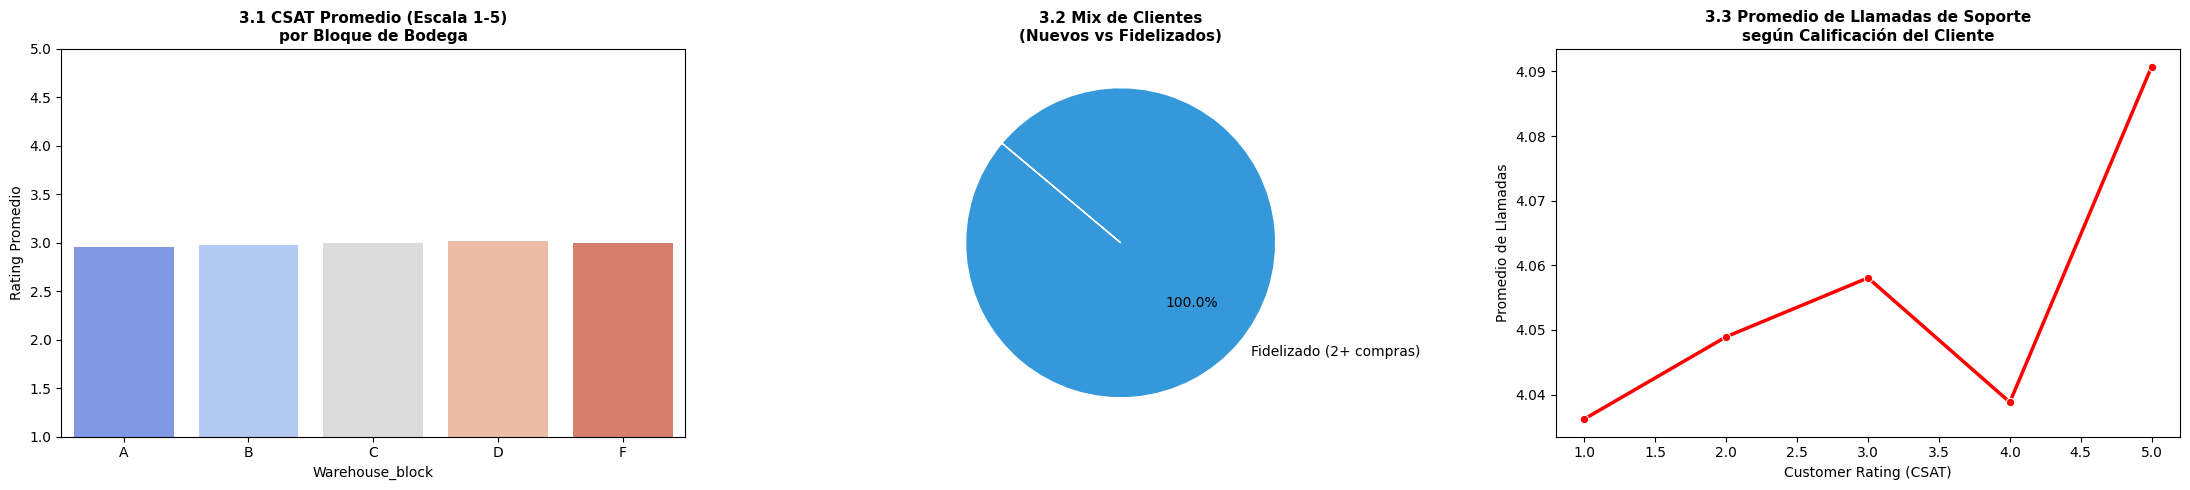

In [10]:
df['Tipo_Cliente'] = np.where(df['Prior_purchases'] <= 1, 'Nuevo (0-1 compras)', 'Fidelizado (2+ compras)')
kpi_3_2 = df['Tipo_Cliente'].value_counts(normalize=True).reset_index()
kpi_3_2.columns = ['Tipo_Cliente', 'Porcentaje']
kpi_3_2['Porcentaje'] = kpi_3_2['Porcentaje'] * 100

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

kpi_3_1 = df.groupby('Warehouse_block')['Customer_rating'].mean().reset_index()
sns.barplot(data=kpi_3_1, x='Warehouse_block', y='Customer_rating', hue='Warehouse_block', ax=axes[0], palette='coolwarm', legend=False)
axes[0].set_title('3.1 CSAT Promedio (Escala 1-5)\npor Bloque de Bodega', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Rating Promedio')
axes[0].set_ylim(1, 5)

axes[1].pie(kpi_3_2['Porcentaje'], labels=kpi_3_2['Tipo_Cliente'], autopct='%1.1f%%', 
        colors=['#3498db', '#2ecc71'], startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('3.2 Mix de Clientes\n(Nuevos vs Fidelizados)', fontsize=11, fontweight='bold')

kpi_3_3 = df.groupby('Customer_rating')['Customer_care_calls'].mean().reset_index()
sns.lineplot(data=kpi_3_3, x='Customer_rating', y='Customer_care_calls', marker='o', color='red', ax=axes[2], linewidth=2.5)
axes[2].set_title('3.3 Promedio de Llamadas de Soporte\nsegún Calificación del Cliente', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Promedio de Llamadas')
axes[2].set_xlabel('Customer Rating (CSAT)')

plt.tight_layout()
plt.show()
